In [1]:
import os
print(os.getcwd())
os.chdir('/Users/anivenkat/Slippery_Surface_Pipeline')


/Users/anivenkat/Slippery_Surface_Pipeline


In [2]:
os.environ["IMAGEIO_FFMPEG_EXE"] = "/opt/homebrew/bin/ffmpeg"

In [3]:
%load_ext autoreload
%autoreload 2

from src import (
    data_loader as dl,
    plane_functions as plf,
)

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import os

In [4]:
# load HDF file as dict of dataframes
cfg = dl.load_config("config.yml")
data = dl.load_data_hdf(cfg['datafile'])

INFO: loading file /Users/anivenkat/Slippery_Surface_Pipeline/Data/P9_oDN1_SS_all_Nov2022_V3_092520231.h5



AttributeError: Can't get attribute '_unpickle_block' on <module 'pandas._libs.internals' from '/Users/anivenkat/anaconda3/lib/python3.11/site-packages/pandas/_libs/internals.cpython-311-darwin.so'>

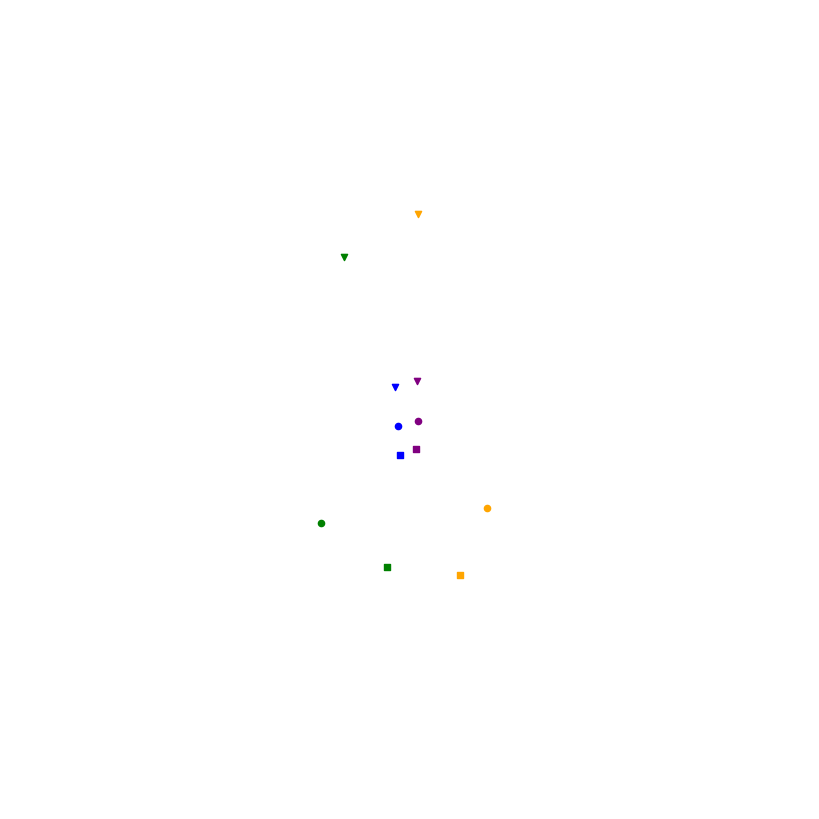

In [1170]:
def plot_plane(df, plane_coefficients):
    a, b, c, d = plane_coefficients

        
    frame = 90
    
    lwh = plf.get_xyz_mean(df, 'L-WH')
    rwh = plf.get_xyz_mean(df, 'R-WH')
    
    L_F = plf.get_xyz_mean(df[df['fnum'] == frame], 'L-F-TaG')
    L_M = plf.get_xyz_mean(df[df['fnum'] == frame], 'L-M-TaG')
    L_H = plf.get_xyz_mean(df[df['fnum'] == frame], 'L-H-TaG')
    R_F = plf.get_xyz_mean(df[df['fnum'] == frame], 'R-F-TaG')
    R_M = plf.get_xyz_mean(df[df['fnum'] == frame], 'R-M-TaG')
    R_H = plf.get_xyz_mean(df[df['fnum'] == frame], 'R-H-TaG')
    
    L_F_ThC = plf.get_xyz_mean(df[df['fnum'] == frame], 'L-F-ThC')
    L_M_ThC = plf.get_xyz_mean(df[df['fnum'] == frame], 'L-M-ThC')
    L_H_ThC = plf.get_xyz_mean(df[df['fnum'] == frame], 'L-H-ThC')
    R_F_ThC = plf.get_xyz_mean(df[df['fnum'] == frame], 'R-F-ThC')
    R_M_ThC = plf.get_xyz_mean(df[df['fnum'] == frame], 'R-M-ThC')
    R_H_ThC = plf.get_xyz_mean(df[df['fnum'] == frame], 'R-H-ThC')



    x = np.linspace(lwh[0] - 1, rwh[0] + 1, 10)
    y = np.linspace(lwh[1] - 1, rwh[1] + 1, 10)
    x, y = np.meshgrid(x, y)
    
    if c != 0:
        z = (-a * x - b * y - d) / c
    else:
        z = np.zeros_like(x)

    fig = plt.figure(figsize=(10,8))
    fig.subplots_adjust(top=1, bottom=0, left=0, right=1, wspace=0)
    ax = fig.add_subplot(projection='3d')

    #ax.plot_surface(x, y, z, alpha=0.15)

    ax.scatter(*L_F, color='green', label='L-F-TaG', marker='v')
    ax.scatter(*L_M, color='green', label='L-M-TaG')
    ax.scatter(*L_H, color='green', label='L-H-TaG', marker='s')
    
    ax.scatter(*R_F, color='orange', label='R-F-TaG', marker='v')
    ax.scatter(*R_M, color='orange', label='R-M-TaG')
    ax.scatter(*R_H, color='orange', label='R-H-TaG', marker='s')
    
    ax.scatter(*L_F_ThC, color='blue', label='L-F-ThC', marker='v')
    ax.scatter(*L_M_ThC, color='blue', label='L-M-ThC')
    ax.scatter(*L_H_ThC, color='blue', label='L-H-ThC', marker='s')
    
    ax.scatter(*R_F_ThC, color='purple', label='R-F-ThC', marker='v')
    ax.scatter(*R_M_ThC, color='purple', label='R-M-ThC')
    ax.scatter(*R_H_ThC, color='purple', label='R-H-ThC', marker='s')

    
    ax.view_init(elev = -180, azim = 90, roll=-90)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_axis_off()
    ax.set_zlim3d(86, 94)
    ax.set_xlim3d(-2, 2.5)

    

    plt.show()
plot_plane(df, plane)

In [5]:
flynum=1
trial=1
genotype = 'P9RT_SS'

df = data[genotype][data[genotype]['flynum']==flynum]
plane = plf.fit_plane(df)
plf.plot_plane(df, plane)


NameError: name 'data' is not defined

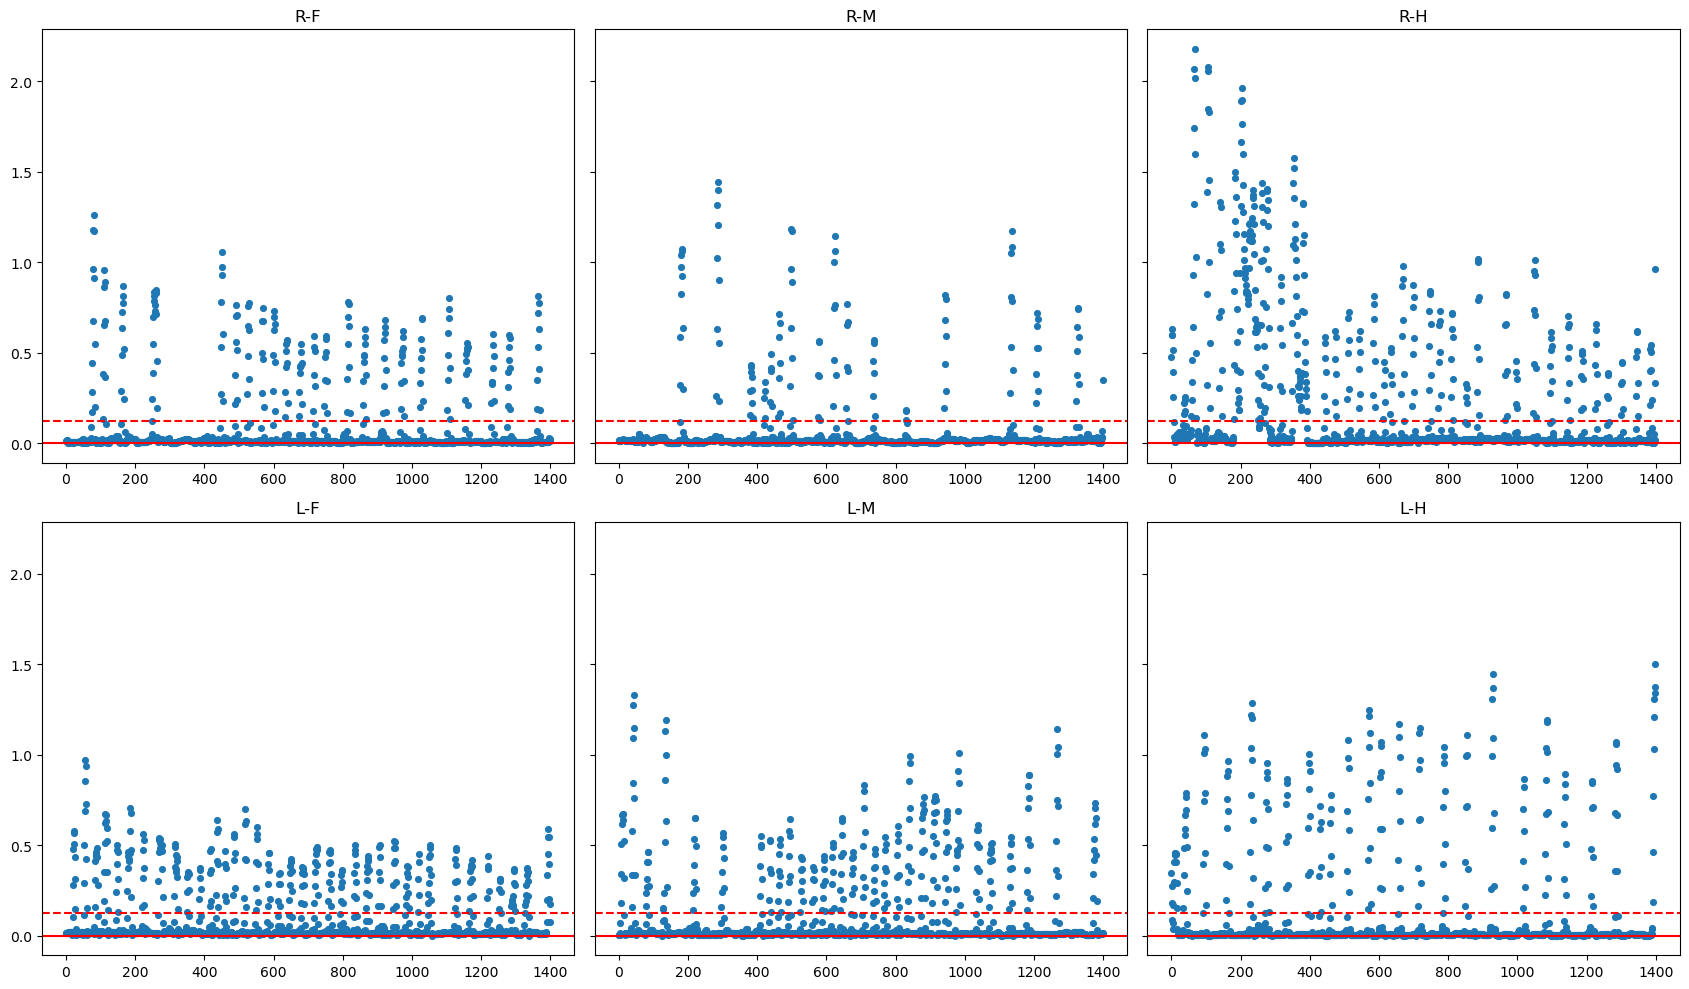

In [1136]:
r_med = {'R-F': 0.175, 'R-M': 0.175, 'R-H': 0.175, 'L-F': 0.175, 'L-M': 0.175, 'L-H': 0.175}



df = plf.add_distance(df, plane)


plf.distance_from_surface_plots(df, r_med, flynum, trial, size=17, save=False, genotype=genotype, path = cfg['output_folder'])

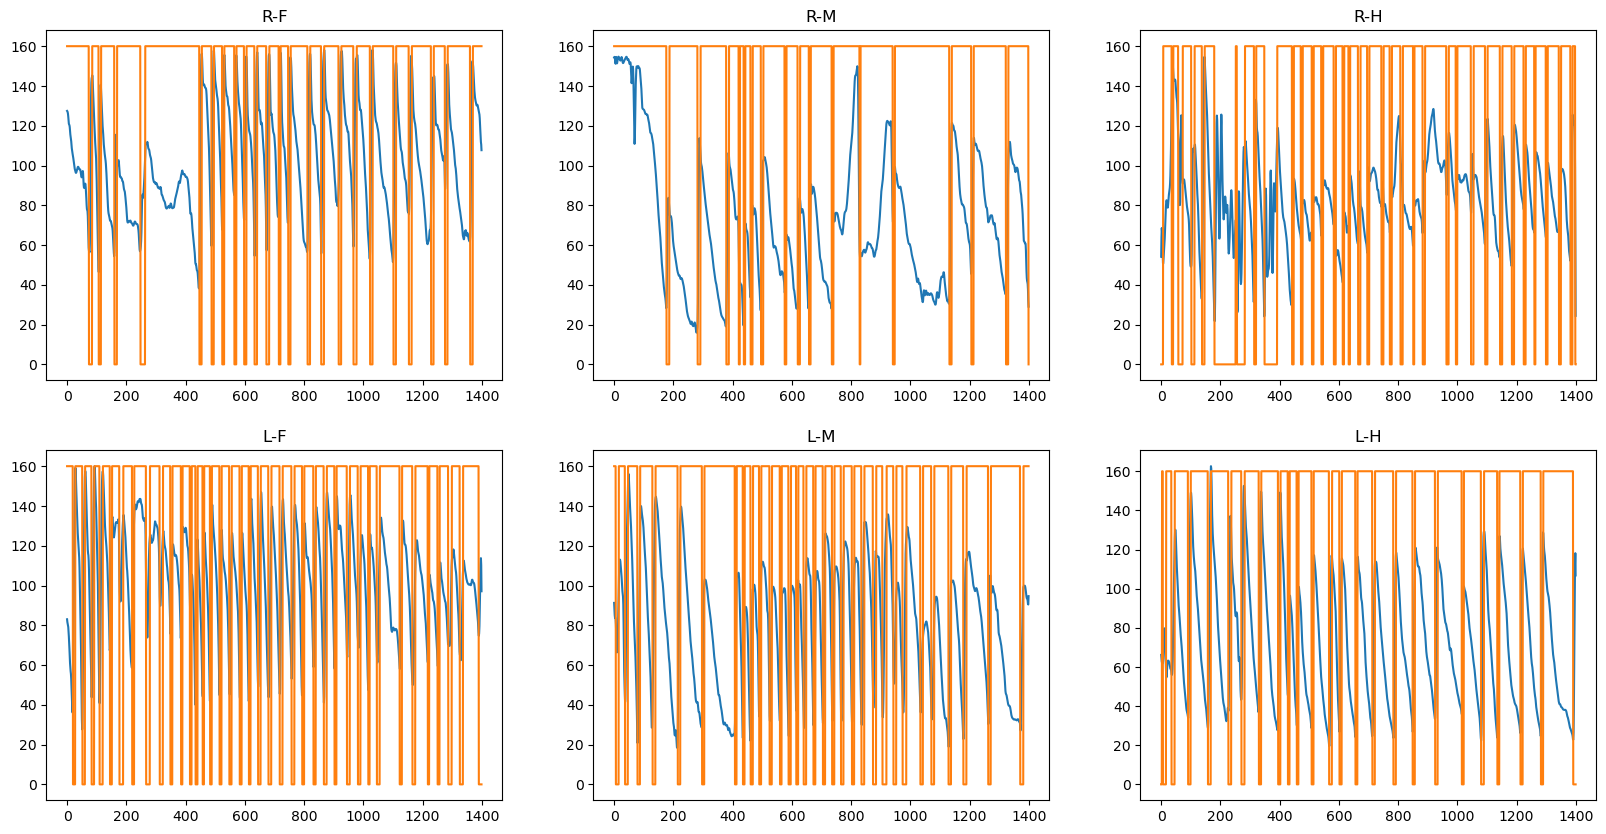

In [1138]:
df = plf.add_stepcycle_pred(df, r_med, min_on=2, min_off=2)
plf.step_cycle_plots(df, flynum, trial=trial, angle='C', save=False, genotype=genotype, path = cfg['output_folder'])

In [22]:
plf.plot_plane_gif(df, plane, cfg['output_folder'], flynum, genotype)

100%|██████████| 180/180 [00:04<00:00, 36.82it/s]


In [1173]:
plf.plot_walk_vid(df, cfg['output_folder'], flynum, genotype, trial)

100%|██████████| 1400/1400 [14:57<00:00,  1.56it/s] 


Moviepy - Building video /Users/anivenkat/Slippery_Surface_Pipeline/outputs/P9RT_SS_fly1_trial1.mp4.
Moviepy - Writing video /Users/anivenkat/Slippery_Surface_Pipeline/outputs/P9RT_SS_fly1_trial1.mp4



Moviepy - Done !
Moviepy - video ready /Users/anivenkat/Slippery_Surface_Pipeline/outputs/P9RT_SS_fly1_trial1.mp4
